Primero vamos precomputar los valores de coherencia de todos los segmentos de la intancia de validación. Quedarán guardados en cache haciendo mucho mas eficiente el ajuste de parametros e hiperparametros.

In [2]:
from data_loader import load_dataset
from llm import get_coherence


# Cargar todas las instancias
dataset = load_dataset()

# Tomar solo las tres primeras
validation_instances = dataset[:3]

for idx, instance in enumerate(validation_instances):
    contents, solution = instance
    n = len(contents)

    # Número total de segmentos de longitud >= 2 (i desde 0 hasta n-2, j desde i+2 hasta n)
    total_segments = sum(1 for i in range(n) for j in range(i+2, n+1))

    print(f"\n=== Instancia {idx+1} (n={n}) ===")
    print(f"Precomputando {total_segments} segmentos...")

    count = 0
    for i in range(n):
        for j in range(i+2, n+1):
            get_coherence(contents, i, j)
            count += 1
            print(f"\rProgreso: {100 * count / total_segments:.1f}%", end="")

    print("\n✔ Precomputación completada para esta instancia.\n")

print("✅ Precomputación finalizada para las tres instancias de validación.")


=== Instancia 1 (n=20) ===
Precomputando 190 segmentos...
Progreso: 100.0%
✔ Precomputación completada para esta instancia.


=== Instancia 2 (n=15) ===
Precomputando 105 segmentos...
Progreso: 100.0%
✔ Precomputación completada para esta instancia.


=== Instancia 3 (n=20) ===
Precomputando 190 segmentos...
Progreso: 100.0%
✔ Precomputación completada para esta instancia.

✅ Precomputación finalizada para las tres instancias de validación.


# Experimento 1: Ajuste de la función objetivo

Se va usar una solución con programación dinámica, útil solo para instancias pequeñas, para probar distintas combinaciones y elegir la que mejor métrica F1 tiene.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from typing import List, Tuple, Callable, Dict
from sklearn.metrics import f1_score, accuracy_score
import pandas as pd



# Configuración para gráficos en Jupyter (opcional, suele ser automático)
%matplotlib inline

# ------------------------------------------------------------
# 1. Métrica de comparación entre cortes predichos y reales
# ------------------------------------------------------------
def evaluate_cuts(pred_cuts: List[int], true_cuts: List[int]) -> Dict[str, float]:
    """
    Calcula varias métricas entre dos vectores binarios de cortes.
    Asume que ambos tienen la misma longitud.
    """
    if len(pred_cuts) != len(true_cuts):
        raise ValueError("Los vectores de cortes deben tener la misma longitud")
    f1 = f1_score(true_cuts, pred_cuts, zero_division=0)
    acc = accuracy_score(true_cuts, pred_cuts)
    hamming = np.mean(np.array(pred_cuts) != np.array(true_cuts))
    return {"f1": f1, "accuracy": acc, "hamming_distance": hamming}


# ------------------------------------------------------------
# 2. Experimento de búsqueda de parámetros
# ------------------------------------------------------------
def tune_parameters(
    examples: List[Tuple[List[str], List[int]]],
    unit_range: Tuple[float, float, float] = (0.0, 2.0, 0.1),
    alpha_range: Tuple[float, float, float] = (0.0, 1.5, 0.1),
    metric: str = "f1"
) -> Tuple[pd.DataFrame, Dict]:
    """
    Realiza búsqueda en cuadrícula sobre unit_coherence y alpha.
    Retorna: (DataFrame con todos los resultados, dict con mejores parámetros)
    """
    unit_vals = np.arange(unit_range[0], unit_range[1] + unit_range[2]/2, unit_range[2])
    alpha_vals = np.arange(alpha_range[0], alpha_range[1] + alpha_range[2]/2, alpha_range[2])
    
    results = []
    for unit_coh in unit_vals:
        for alpha in alpha_vals:
            scores = []
            for contents, true_cuts in examples:
                pred_cuts, _ = dp_solution(                    
                    contents=contents,
                    unit_coherence=unit_coh,
                    alpha=alpha
                )
                if len(pred_cuts) != len(true_cuts):
                    continue
                metrics = evaluate_cuts(pred_cuts, true_cuts)
                scores.append(metrics[metric])
            mean_score = np.mean(scores) if scores else 0.0
            results.append({
                "unit_coherence": unit_coh,
                "alpha": alpha,
                "mean_score": mean_score,
                "std_score": np.std(scores) if scores else 0.0
            })
    df = pd.DataFrame(results)
    best = df.loc[df["mean_score"].idxmax()].to_dict()
    return df, best


# ------------------------------------------------------------
# 3. Visualización de resultados 
# ------------------------------------------------------------
def plot_parameter_heatmap(df: pd.DataFrame, metric_name: str = "F1-score"):
    """Mapa de calor de la métrica media en función de unit_coherence y alpha."""
    pivot = df.pivot(index="unit_coherence", columns="alpha", values="mean_score")
    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", cbar_kws={'label': metric_name})
    plt.title(f"Rendimiento medio ({metric_name}) según parámetros")
    plt.xlabel("Alpha (penalización por segmento)")
    plt.ylabel("Coherencia unitaria")
    plt.show()


def plot_3d_surface(df: pd.DataFrame, metric_name: str = "F1-score"):
    """Superficie 3D de la métrica."""
    pivot = df.pivot(index="unit_coherence", columns="alpha", values="mean_score")
    X, Y = np.meshgrid(pivot.columns, pivot.index)
    Z = pivot.values
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
    ax.set_xlabel('Alpha')
    ax.set_ylabel('Unit coherence')
    ax.set_zlabel(metric_name)
    ax.set_title(f'Superficie de {metric_name}')
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    plt.show()


for contents,solution in validation_instances:
    df_resultados, mejor = tune_parameters(
        examples=[(contents,solution)],                         # lista de (contents, cuts)
        unit_range=(0.0, 1.0, 0.1),
        alpha_range=(0.0, 1.0, 0.1),
        metric="f1"
    )

    # Mejores parámetros
    print("\n🏆 Mejores parámetros encontrados:")
    print(f"  unit_coherence = {mejor['unit_coherence']:.3f}")
    print(f"  alpha = {mejor['alpha']:.3f}")
    print(f"  {mejor['mean_score']:.4f} (F1-score medio)")

    # Visualizar gráficas
    plot_parameter_heatmap(df_resultados, metric_name="F1-score")
#plot_3d_surface(df_resultados, metric_name="F1-score")

NameError: name 'dp_solution' is not defined

## Resultados:
- Valores altos de coherencia unitaria y valores bajos de penalización por segmentación dan malos resultados
- Aunque un alpha = 1 implica valores negativos en la función de evaluación, es óptimo.
- Dado que la solución óptima puede incluir en algún caso un segmento unitario, se establecerá la coherencia unitaria por defecto en 0.6 (ligeramente coherente). En los casos en que no, la alta penalización por segmentación debería evitar los segmentos unitarios.

# Experimento 2: Ajuste de parámetros de las metaheurísticas

In [5]:
# =========================================================================
# Imports y configuración
# =========================================================================
import math, random, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Any, Tuple



# # Ajusta las rutas a tus módulos
from metaheuristics import HillClimbing, SimulatedAnnealing, GeneticAlgorithm, ParticleSwarmOptimization
from tuning import evaluate_config


def get_random_params(param_ranges, num_samples):
    sampled_params = []
    for _ in range(num_samples):
        params = {}
        for param_name, param_definition in param_ranges.items():            
            params[param_name] = random.choice(param_definition)            
        sampled_params.append(params)
    return sampled_params

## Hill Climbing

HC {'stagnation_limit': 150, 'max_evaluations': 500, 'neighborhood_size': 5}: F1 medio = 0.8571 (fitness real medio = -0.3667)
HC {'stagnation_limit': 50, 'max_evaluations': 5000, 'neighborhood_size': 1}: F1 medio = 0.7143 (fitness real medio = -0.5333)
HC {'stagnation_limit': 150, 'max_evaluations': 1000, 'neighborhood_size': 5}: F1 medio = 1.0000 (fitness real medio = -0.2000)
HC {'stagnation_limit': 200, 'max_evaluations': 500, 'neighborhood_size': 3}: F1 medio = 1.0000 (fitness real medio = -0.2000)
HC {'stagnation_limit': 200, 'max_evaluations': 1000, 'neighborhood_size': 1}: F1 medio = 0.8571 (fitness real medio = -0.3667)
HC {'stagnation_limit': 150, 'max_evaluations': 500, 'neighborhood_size': 3}: F1 medio = 1.0000 (fitness real medio = -0.2000)
HC {'stagnation_limit': 50, 'max_evaluations': 500, 'neighborhood_size': 1}: F1 medio = 1.0000 (fitness real medio = -0.2000)
HC {'stagnation_limit': 100, 'max_evaluations': 1000, 'neighborhood_size': 3}: F1 medio = 1.0000 (fitness real

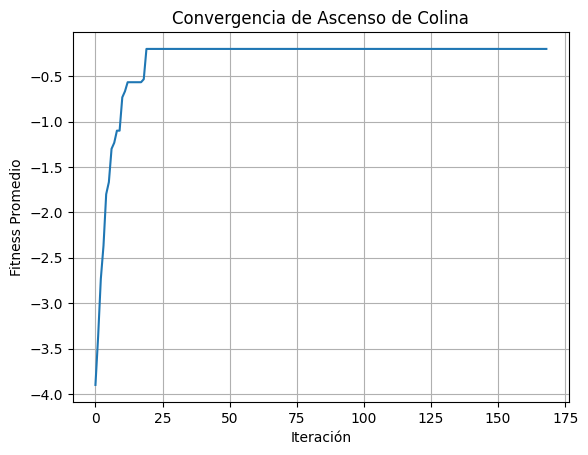

In [3]:
hc_param_grid = {
    'stagnation_limit': [50, 100, 150, 200],
    'max_evaluations': [500, 1000, 5000],
    'neighborhood_size': [1, 3, 5]
}

results_hc = []
num_random_configs = 10
hc_random_params = get_random_params(hc_param_grid, num_random_configs)

for params in hc_random_params:
    res = evaluate_config(HillClimbing, params, [validation_instances[0]], num_reps=3)
    results_hc.append(res)
    print(f"HC {params}: F1 medio = {np.mean(res['f1_scores']):.4f} "
          f"(fitness real medio = {np.mean(res['final_fitness']):.4f})")

best_hc = max(results_hc, key=lambda r: np.mean(r['f1_scores']))
plt.plot(best_hc['avg_history'])
plt.xlabel('Iteración')
plt.ylabel('Fitness Promedio')
plt.title(f"Convergencia de Ascenso de Colina")
plt.grid(True)
plt.show()

## Simulated Anealing

SA {'T0': 50.0, 'alpha': 0.9, 'iters_per_temp': 20, 'max_evaluations': 5000, 'T_min': 0.001}: F1 medio = 0.3810(fitness real medio = -0.7000)
SA {'T0': 50.0, 'alpha': 0.9, 'iters_per_temp': 20, 'max_evaluations': 2000, 'T_min': 0.001}: F1 medio = 0.5820(fitness real medio = -0.6667)
SA {'T0': 10.0, 'alpha': 0.95, 'iters_per_temp': 20, 'max_evaluations': 1000, 'T_min': 0.001}: F1 medio = 0.4762(fitness real medio = -0.7000)
SA {'T0': 10.0, 'alpha': 0.99, 'iters_per_temp': 20, 'max_evaluations': 5000, 'T_min': 0.001}: F1 medio = 0.4762(fitness real medio = -0.7000)
SA {'T0': 10.0, 'alpha': 0.8, 'iters_per_temp': 20, 'max_evaluations': 5000, 'T_min': 0.001}: F1 medio = 0.4762(fitness real medio = -0.7000)
SA {'T0': 50.0, 'alpha': 0.8, 'iters_per_temp': 5, 'max_evaluations': 2000, 'T_min': 0.001}: F1 medio = 0.6349(fitness real medio = -0.6000)
SA {'T0': 100.0, 'alpha': 0.9, 'iters_per_temp': 20, 'max_evaluations': 1000, 'T_min': 0.001}: F1 medio = 0.4405(fitness real medio = -0.7667)
SA {

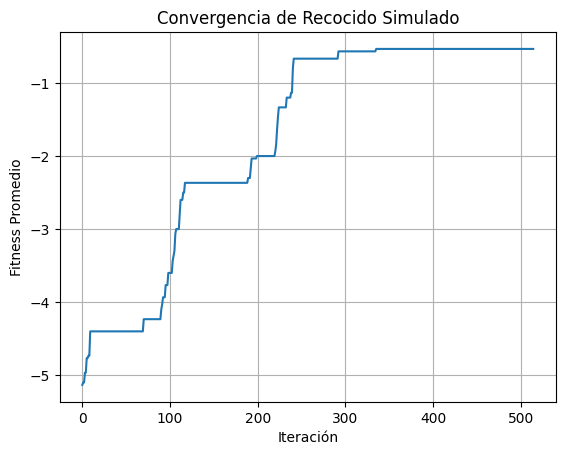

In [5]:
sa_param_grid = {
    'T0': [10.0, 50.0, 100.0],
    'alpha': [0.8, 0.9, 0.95, 0.99],
    'iters_per_temp': [5, 10, 20, 50],
    'max_evaluations': [1000, 2000, 5000]
}
# T_min fijo pequeño
FIXED_SA_T_MIN = 1e-3


results_sa = []
num_random_configs = 10
sa_random_params = get_random_params(sa_param_grid, num_random_configs)

for params in sa_random_params:
    current_params = params.copy()
    current_params['T_min'] = FIXED_SA_T_MIN
    res = evaluate_config(SimulatedAnnealing, current_params, [validation_instances[0]],3)
    results_sa.append(res)
    print(f"SA {current_params}: F1 medio = {np.mean(res['f1_scores']):.4f}"
            f"(fitness real medio = {np.mean(res['final_fitness']):.4f})")




best_sa = max(results_sa, key=lambda r: np.mean(r['f1_scores']))
plt.plot(best_sa['avg_history'])
plt.xlabel('Iteración')
plt.ylabel('Fitness Promedio')
plt.title(f"Convergencia de Recocido Simulado")
plt.grid(True)
plt.show()

## Algoritmo genético

GA {'population_size': 50, 'mutation_rate': 0.05, 'elitism': 1, 'max_generations': 100, 'max_evaluations': 5000}: F1 medio = 1.0000
GA {'population_size': 10, 'mutation_rate': 0.1, 'elitism': 5, 'max_generations': 50, 'max_evaluations': 1000}: F1 medio = 0.7778
GA {'population_size': 10, 'mutation_rate': 0.05, 'elitism': 5, 'max_generations': 50, 'max_evaluations': 5000}: F1 medio = 0.6778
GA {'population_size': 50, 'mutation_rate': 0.05, 'elitism': 1, 'max_generations': 20, 'max_evaluations': 5000}: F1 medio = 1.0000
GA {'population_size': 50, 'mutation_rate': 0.1, 'elitism': 3, 'max_generations': 100, 'max_evaluations': 5000}: F1 medio = 0.7619
GA {'population_size': 20, 'mutation_rate': 0.01, 'elitism': 3, 'max_generations': 100, 'max_evaluations': 5000}: F1 medio = 0.5464
GA {'population_size': 50, 'mutation_rate': 0.05, 'elitism': 3, 'max_generations': 100, 'max_evaluations': 1000}: F1 medio = 1.0000
GA {'population_size': 20, 'mutation_rate': 0.1, 'elitism': 5, 'max_generations':

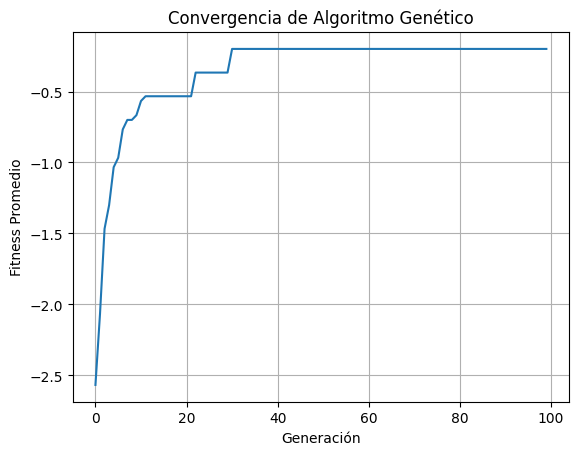

In [3]:
ga_param_grid = {
    'population_size': [10, 20, 50],
    'mutation_rate': [0.01, 0.05, 0.1],
    'elitism': [1, 3, 5],
    'max_generations': [20, 50, 100],
    'max_evaluations': [1000, 5000]
}


results_ga = []
num_random_configs = 10
ga_random_params = get_random_params(ga_param_grid, num_random_configs)

for params in ga_random_params:
    res = evaluate_config(GeneticAlgorithm, params, [validation_instances[0]], num_reps=3)
    results_ga.append(res)
    print(f"GA {params}: F1 medio = {np.mean(res['f1_scores']):.4f}")

df_ga = pd.DataFrame([
    {'pop': r['params']['population_size'],
     'mut': r['params']['mutation_rate'],
     'elit': r['params']['elitism'],
     'F1': f}
    for r in results_ga for f in r['f1_scores']
])



best_ga = max(results_ga, key=lambda r: np.mean(r['f1_scores']))
plt.plot(best_ga['avg_history'])
plt.xlabel('Generación')
plt.ylabel('Fitness Promedio')
plt.title("Convergencia de Algoritmo Genético")
plt.grid(True)
plt.show()

## Enjambre de Partículas

PSO {'population_size': 10, 'w': 0.9, 'c1': 2.5, 'c2': 2.0, 'max_generations': 100, 'max_evaluations': 5000, 'v_max': 2.0}: F1 medio = 0.9195
PSO {'population_size': 50, 'w': 0.7, 'c1': 1.0, 'c2': 2.0, 'max_generations': 20, 'max_evaluations': 1000, 'v_max': 10.0}: F1 medio = 0.9117
PSO {'population_size': 10, 'w': 0.5, 'c1': 2.0, 'c2': 1.5, 'max_generations': 50, 'max_evaluations': 5000, 'v_max': 2.0}: F1 medio = 0.8012
PSO {'population_size': 50, 'w': 0.9, 'c1': 1.0, 'c2': 2.5, 'max_generations': 50, 'max_evaluations': 1000, 'v_max': 2.0}: F1 medio = 0.8779
PSO {'population_size': 50, 'w': 0.7, 'c1': 1.0, 'c2': 2.0, 'max_generations': 50, 'max_evaluations': 5000, 'v_max': 2.0}: F1 medio = 0.9405
PSO {'population_size': 50, 'w': 0.7, 'c1': 2.0, 'c2': 2.0, 'max_generations': 100, 'max_evaluations': 5000, 'v_max': 5.0}: F1 medio = 1.0000
PSO {'population_size': 20, 'w': 0.7, 'c1': 1.5, 'c2': 1.0, 'max_generations': 50, 'max_evaluations': 1000, 'v_max': 5.0}: F1 medio = 0.8824
PSO {'popu

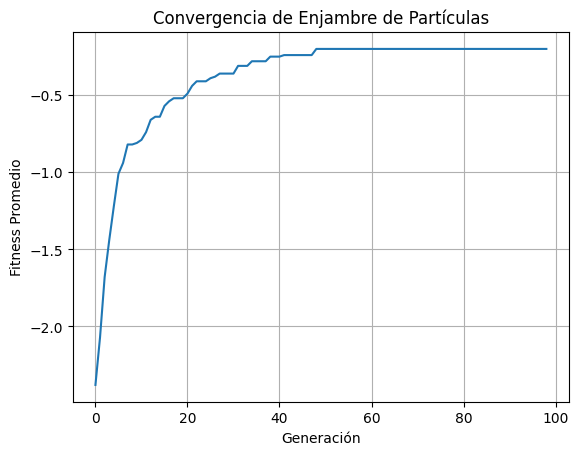

In [ ]:
pso_param_grid = {
    'population_size': [10, 20, 50],
    'w': [0.5, 0.7, 0.9],
    'c1': [1.0, 1.5, 2.0, 2.5],
    'c2': [1.0, 1.5, 2.0, 2.5],
    'max_generations': [20,50, 100],
    'max_evaluations': [1000, 5000],
    'v_max': [2.0, 5.0, 10.0]
}


results_pso = []
num_random_configs = 10
pso_random_params = get_random_params(pso_param_grid, num_random_configs)

for params in pso_random_params:
    res = evaluate_config(ParticleSwarmOptimization, params, [validation_instances[0]], num_reps=10)
    results_pso.append(res)
    print(f"PSO {params}: F1 medio = {np.mean(res['f1_scores']):.4f}")

best_pso = max(results_pso, key=lambda r: np.mean(r['f1_scores']))
plt.plot(best_pso['avg_history'])
plt.xlabel('Generación')
plt.ylabel('Fitness Promedio')

plt.title(f"Convergencia de Enjambre de Partículas")
plt.grid(True)
plt.show()

# Experimento 3: Evaluación de las metaheurísticas

Se evaluarán las 4 metaheurísticas con sus mejores parámetros encontrados en el Experimento 2 sobre las instancias de prueba (4-8, índices 3-7). Se comparará la media F1 para seleccionar la mejor estrategia.

In [3]:
# Cargar las instancias de prueba (4-8, índices 3-7)
test_instances = dataset[3:8]

print(f"Cargadas {len(test_instances)} instancias de prueba:")
for idx, instance in enumerate(test_instances):
    contents, solution = instance
    print(f"  Instancia {idx + 4}: n={len(contents)} elementos, {sum(solution)} cortes")

# Inicializar diccionario para resultados
results_test = {}

Cargadas 5 instancias de prueba:
  Instancia 4: n=20 elementos, 4 cortes
  Instancia 5: n=20 elementos, 4 cortes
  Instancia 6: n=20 elementos, 5 cortes
  Instancia 7: n=20 elementos, 3 cortes
  Instancia 8: n=20 elementos, 3 cortes


### Hill Climbing

In [6]:
print("Evaluando Hill Climbing...")
best_params_hc = {'stagnation_limit': 150, 'max_evaluations': 500, 'neighborhood_size': 3}
print(f"Parámetros: {best_params_hc}")

result_hc = evaluate_config(HillClimbing, best_params_hc, test_instances)
results_test["Hill Climbing"] = result_hc

f1_mean = np.mean(result_hc['f1_scores'])
f1_std = np.std(result_hc['f1_scores'])
print(f"✓ F1-score medio: {f1_mean:.4f} ± {f1_std:.4f}")
print(f"  Fitness real medio: {np.mean(result_hc['final_fitness']):.4f}\n")

%store result_hc

Evaluando Hill Climbing...
Parámetros: {'stagnation_limit': 150, 'max_evaluations': 500, 'neighborhood_size': 3}
✓ F1-score medio: 0.7162 ± 0.0000
  Fitness real medio: -0.4700

Stored 'result_hc' (dict)


### Simulated Annealing

In [ ]:
print("Evaluando Simulated Annealing...")
best_params_sa = {'T0': 50.0, 'alpha': 0.8, 'iters_per_temp': 5, 'max_evaluations': 1000, 'T_min': 0.001}
print(f"Parámetros: {best_params_sa}")

result_sa = evaluate_config(SimulatedAnnealing, best_params_sa, test_instances)
results_test["Simulated Annealing"] = result_sa

f1_mean = np.mean(result_sa['f1_scores'])
f1_std = np.std(result_sa['f1_scores'])
print(f"✓ F1-score medio: {f1_mean:.4f} ± {f1_std:.4f}")
print(f"  Fitness real medio: {np.mean(result_sa['final_fitness']):.4f}\n")

%store result_sa

Evaluando Simulated Annealing...
Parámetros: {'T0': 50.0, 'alpha': 0.8, 'iters_per_temp': 5, 'max_evaluations': 1000, 'T_min': 0.001}
🛑 [Error 429] Resource exhausted with key AIzaSyA6... (failure 1/5). Rotating key and waiting 2.0s
🔄 Rotating credential to index: 1
✓ F1-score medio: 0.5447 ± 0.1316
  Fitness real medio: -0.5540

Stored 'result_sa' (dict)


### Algoritmo Genético

In [9]:
print("Evaluando Algoritmo Genético...")
best_params_ga = {'population_size': 50, 'mutation_rate': 0.05, 'elitism': 3, 'max_generations': 100, 'max_evaluations': 1000}
print(f"Parámetros: {best_params_ga}")

result_ga = evaluate_config(GeneticAlgorithm, best_params_ga, test_instances)
results_test["Genetic Algorithm"] = result_ga

f1_mean = np.mean(result_ga['f1_scores'])
f1_std = np.std(result_ga['f1_scores'])
print(f"✓ F1-score medio: {f1_mean:.4f} ± {f1_std:.4f}")
print(f"  Fitness real medio: {np.mean(result_ga['final_fitness']):.4f}\n")

%store result_ga

Evaluando Algoritmo Genético...
Parámetros: {'population_size': 50, 'mutation_rate': 0.05, 'elitism': 3, 'max_generations': 100, 'max_evaluations': 1000}


⚠️ Error (RemoteProtocolError): Server disconnected without sending a response. with key AIzaSyCS... (failure 1/5). Retrying with same key in 2.0s
✓ F1-score medio: 0.8814 ± 0.0000
  Fitness real medio: -0.3100

Stored 'result_ga' (dict)


### Particle Swarm Optimization

In [10]:
print("Evaluando Particle Swarm Optimization...")
best_params_pso = {'population_size': 50, 'w': 0.7, 'c1': 2.0, 'c2': 2.0, 'max_generations': 100, 'max_evaluations': 1000, 'v_max': 5.0}
print(f"Parámetros: {best_params_pso}")

result_pso = evaluate_config(ParticleSwarmOptimization, best_params_pso, test_instances)
results_test["Particle Swarm Optimization"] = result_pso

f1_mean = np.mean(result_pso['f1_scores'])
f1_std = np.std(result_pso['f1_scores'])
print(f"✓ F1-score medio: {f1_mean:.4f} ± {f1_std:.4f}")
print(f"  Fitness real medio: {np.mean(result_pso['final_fitness']):.4f}\n")

%store result_pso

Evaluando Particle Swarm Optimization...
Parámetros: {'population_size': 50, 'w': 0.7, 'c1': 2.0, 'c2': 2.0, 'max_generations': 100, 'max_evaluations': 1000, 'v_max': 5.0}
✓ F1-score medio: 0.9025 ± 0.0000
  Fitness real medio: -0.2700

Stored 'result_pso' (dict)


## Resultados del Experimento 3


📊 Resumen de resultados en instancias de prueba:
             Metaheurística  F1-medio   F1-std   F1-min   F1-max  Evaluaciones
Particle Swarm Optimization  0.902453 0.000000 0.902453 0.902453          1000
          Genetic Algorithm  0.881429 0.000000 0.881429 0.881429          1037
              Hill Climbing  0.716190 0.000000 0.716190 0.716190           496
        Simulated Annealing  0.544678 0.131627 0.357778 0.734762           246

🏆 MEJOR METAHEURÍSTICA: Particle Swarm Optimization
   F1-score medio: 0.9025



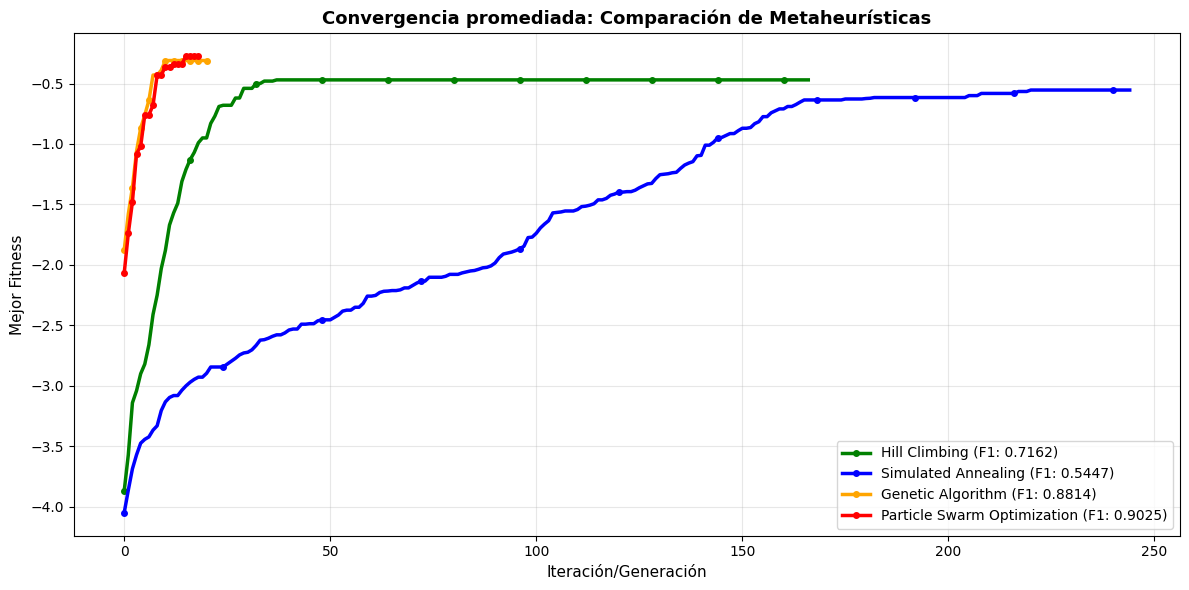

✅ Experimento 3 completado.


In [12]:

%store -r result_hc
%store -r result_sa
%store -r result_ga
%store -r result_pso

results_tests = {
    "Hill Climbing": result_hc,
    "Simulated Annealing": result_sa,
    "Genetic Algorithm": result_ga,
    "Particle Swarm Optimization": result_pso
}

# Crear tabla resumen
summary_data = []
for name, result in results_test.items():
    f1_scores = result['f1_scores']
    summary_data.append({
        'Metaheurística': name,
        'F1-medio': np.mean(f1_scores),
        'F1-std': np.std(f1_scores),
        'F1-min': np.min(f1_scores),
        'F1-max': np.max(f1_scores),
        'Evaluaciones': int(np.mean(result['evaluations']))
    })

summary_df = pd.DataFrame(summary_data).sort_values('F1-medio', ascending=False)
print("\n📊 Resumen de resultados en instancias de prueba:")
print(summary_df.to_string(index=False))

# Seleccionar el mejor
best_metaheuristic = summary_df.iloc[0]
print("\n" + "=" * 60)
print(f"🏆 MEJOR METAHEURÍSTICA: {best_metaheuristic['Metaheurística']}")
print(f"   F1-score medio: {best_metaheuristic['F1-medio']:.4f}")
print("=" * 60 + "\n")

# Gráfico comparativo de convergencia
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['green', 'blue', 'orange', 'red']
for idx, (name, result) in enumerate(results_test.items()):
    ax.plot(result['avg_history'], 
            linewidth=2.5, 
            label=f"{name} (F1: {np.mean(result['f1_scores']):.4f})",
            color=colors[idx],
            marker='o',
            markersize=4,
            markevery=max(1, len(result['avg_history']) // 10))

ax.set_xlabel('Iteración/Generación', fontsize=11)
ax.set_ylabel('Mejor Fitness', fontsize=11)
ax.set_title('Convergencia promediada: Comparación de Metaheurísticas', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Experimento 3 completado.")